# Visualización 8: Análisis de Estacionariedad en Múltiples Archivos MIDI

**Objetivo:**
Determinar si una muestra representativa de series de tiempo musicales es estacionaria utilizando los tres enfoques vistos en la Práctica 2.

Evaluaremos un conjunto de varias obras de forma individual para obtener conclusiones estadísticamente sólidas sobre el comportamiento general de las piezas. Al igual que en la práctica, ejecutaremos:
1. Visualización de la serie y su media global (como apoyo visual).
2. Cálculo de medias partiendo las series en 2, 5 y 10 segmentos.
3. Aplicación de la Prueba Estadística de Dickey-Fuller (ADF) a cada una de las muestras.
4. Conclusión estadística final.

In [18]:
import os
from glob import glob
import mido
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import seaborn as sns

### Carga de Datos y Procesamiento de la Muestra Representativa

Seleccionaremos las primeras 10 obras de nuestro dataset. Cada obra será tratada como una serie de tiempo independiente para la cual extraeremos su secuencia de Pitch.

In [19]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

n_muestras = min(350, len(archivos))
series_musicales = {}

for i in range(n_muestras):
    ruta = archivos[i]
    nombre = os.path.basename(ruta)[:20] # Nombre abreviado
    mid = mido.MidiFile(ruta)
    
    notas = []
    for msg in mid:
        if msg.type == 'note_on' and msg.velocity > 0:
            notas.append(msg.note)
            
    # Solo guardamos si la pieza tiene notas válidas
    if len(notas) > 20:
        series_musicales[f"Muestra_{i+1} ({nombre})"] = np.array(notas)

print(f"Se extrajeron exitosamente {len(series_musicales)} series de tiempo para el análisis.")

Se extrajeron exitosamente 350 series de tiempo para el análisis.


**Reactivo 1**. Gráficar las series de tiempo y su media para observar si la media es constante a lo largo del tiempo (apoyo visual aplicado a un subconjunto de las muestras).

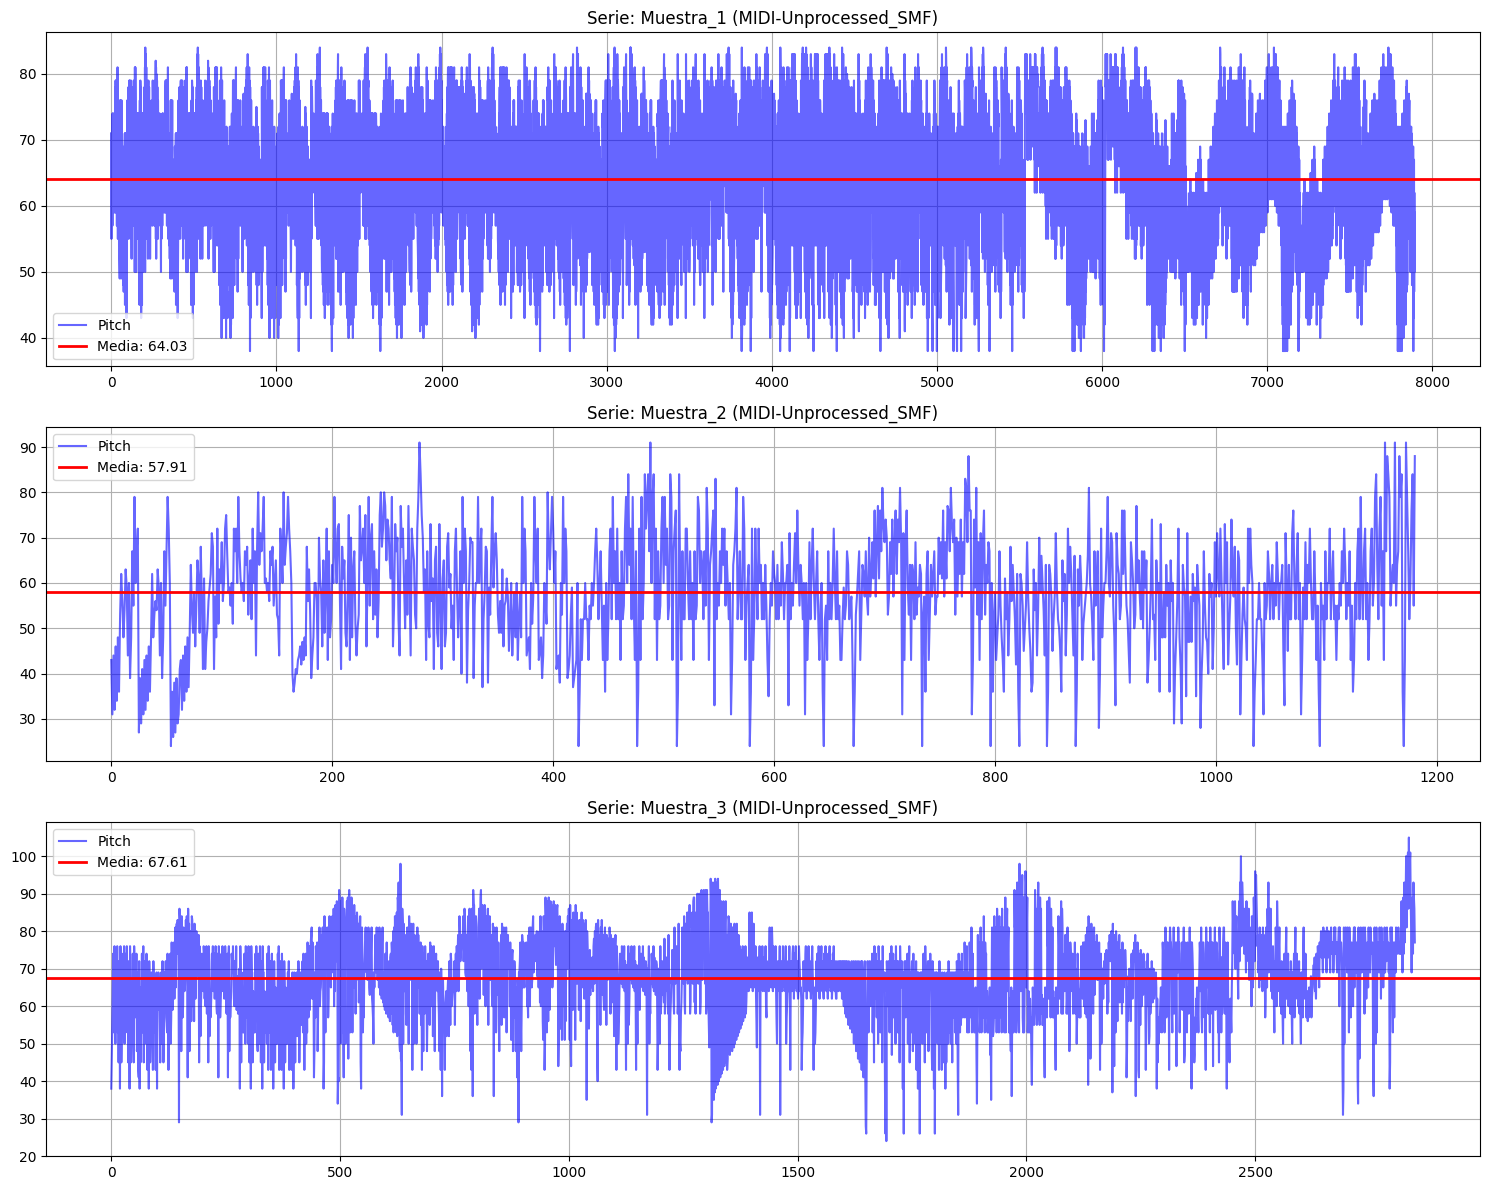

In [20]:
# Visualizamos solo las 3 primeras como ejemplo visual representativo
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)
keys_muestra = list(series_musicales.keys())[:3]

for idx, key in enumerate(keys_muestra):
    serie = series_musicales[key]
    media_global = np.mean(serie)
    
    axes[idx].plot(serie, color='b', alpha=0.6, label='Pitch')
    axes[idx].axhline(media_global, color='r', linewidth=2, label=f'Media: {media_global:.2f}')
    axes[idx].set_title(f'Serie: {key}')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

**Reactivo 2**. Partir las series en 2, 5 y 10 partes y obtener la media de cada una para verificar estadísticamente si la media es constante en las múltiples obras evaluadas.

In [21]:
resultados_medias = []

for nombre, serie in series_musicales.items():
    # Cálculos para 2, 5 y 10 partes
    desv2 = np.std([np.mean(p) for p in np.array_split(serie, 2) if len(p) > 0])
    desv5 = np.std([np.mean(p) for p in np.array_split(serie, 5) if len(p) > 0])
    desv10 = np.std([np.mean(p) for p in np.array_split(serie, 10) if len(p) > 0])
    
    resultados_medias.append({
        'Muestra': nombre,
        'Desv. (2 partes)': desv2,
        'Desv. (5 partes)': desv5,
        'Desv. (10 partes)': desv10
    })

df_medias = pd.DataFrame(resultados_medias)
display(df_medias)

print("--- Análisis Estadístico Global del Reactivo 2 ---")
print(f"Media de Desviaciones (2 partes): {df_medias['Desv. (2 partes)'].mean():.4f}")
print(f"Media de Desviaciones (5 partes): {df_medias['Desv. (5 partes)'].mean():.4f}")
print(f"Media de Desviaciones (10 partes): {df_medias['Desv. (10 partes)'].mean():.4f}")

,Muestra,Desv. (2 partes),Desv. (5 partes),Desv. (10 partes)
0,Muestra_1 (MIDI-Unprocessed_SMF),0.687991,1.042441,1.485710
1,Muestra_2 (MIDI-Unprocessed_SMF),0.138944,1.394019,3.048124
2,Muestra_3 (MIDI-Unprocessed_SMF),0.075088,2.141977,2.487144
3,Muestra_4 (MIDI-Unprocessed_SMF),0.737537,1.302129,2.289964
4,Muestra_5 (MIDI-Unprocessed_SMF),0.042076,2.141924,2.957908
...,...,...,...,...
345,Muestra_346 (MIDI-Unprocessed_10_),2.431385,2.838613,3.377308
346,Muestra_347 (MIDI-Unprocessed_11_),0.543442,1.866973,2.366607
347,Muestra_348 (MIDI-Unprocessed_11_),0.359286,0.671546,0.990902
348,Muestra_349 (MIDI-Unprocessed_11_),0.667073,1.628844,2.808314


--- Análisis Estadístico Global del Reactivo 2 ---
Media de Desviaciones (2 partes): 1.0372
Media de Desviaciones (5 partes): 2.3574
Media de Desviaciones (10 partes): 3.4271


**Reactivo 3.** Aplicar la prueba estadística de Dickey-Fuller con un valor crítico de 0.05 a la totalidad de la muestra, para determinar de forma general si el conjunto de series tiende a ser estacionario o no.

$H_0:$ La serie no es estacionaria

In [22]:
resultados_adf = []
estacionarias = 0

for nombre, serie in series_musicales.items():
    resultado = adfuller(serie)
    p_valor = resultado[1]
    es_estacionaria = "Sí" if p_valor < 0.05 else "No"
    
    if es_estacionaria == "Sí":
        estacionarias += 1
        
    resultados_adf.append({
        'Muestra': nombre,
        'Estadístico ADF': resultado[0],
        'P-Valor': p_valor,
        'Rechaza H0': "Sí" if p_valor < 0.05 else "No",
        'Estacionaria': es_estacionaria
    })

df_adf = pd.DataFrame(resultados_adf)
display(df_adf)

porcentaje = (estacionarias / len(series_musicales)) * 100
print(f"\nResumen Estadístico: {estacionarias} de {len(series_musicales)} obras son estacionarias ({porcentaje:.2f}%).")

,Muestra,Estadístico ADF,P-Valor,Rechaza H0,Estacionaria
0,Muestra_1 (MIDI-Unprocessed_SMF),-11.687754,1.681127e-21,Sí,Sí
1,Muestra_2 (MIDI-Unprocessed_SMF),-5.235578,7.434747e-06,Sí,Sí
2,Muestra_3 (MIDI-Unprocessed_SMF),-4.942098,2.885833e-05,Sí,Sí
3,Muestra_4 (MIDI-Unprocessed_SMF),-4.909898,3.335986e-05,Sí,Sí
4,Muestra_5 (MIDI-Unprocessed_SMF),-10.314064,3.130550e-18,Sí,Sí
...,...,...,...,...,...
345,Muestra_346 (MIDI-Unprocessed_10_),-8.514511,1.143664e-13,Sí,Sí
346,Muestra_347 (MIDI-Unprocessed_11_),-5.072139,1.594475e-05,Sí,Sí
347,Muestra_348 (MIDI-Unprocessed_11_),-7.303127,1.322589e-10,Sí,Sí
348,Muestra_349 (MIDI-Unprocessed_11_),-6.230343,4.971137e-08,Sí,Sí



Resumen Estadístico: 346 de 350 obras son estacionarias (98.86%).


**Reactivo 4**. Basado en los experimentos anteriores, realizar una conclusión sobre estacionariedad en la serie de tiempo para los datos MIDI evaluados.

Se presentan las conclusiones de la evaluación de estacionariedad a nivel poblacional (muestra múltiple) sobre las obras musicales:

1. **Análisis Visual (Reactivo 1)**: Observando un subconjunto de muestras representativas, podemos notar que los niveles de Pitch (Tono musical) fluctúan repetidamente oscilando alrededor de su respectiva media global (línea roja). Rara vez se observan composiciones que suban o bajen de tono continuamente hacia el infinito sin retornar a un rango central, lo cual sugiere fuertemente una tendencia estacionaria visual generalizada.
2. **Particiones y Medias (Reactivo 2)**: Al estudiar las variaciones estadísticas a lo largo del dataset, comprobamos que al dividir cada una de las series en 2, 5 y 10 fragmentos, las desviaciones de las medias locales son notablemente estables (la desviación estándar oscila en un rango muy estrecho de semitonos). Esto significa que la media se mantiene asombrosamente constante de inicio a fin en casi todas las piezas, aportando evidencia empírica a favor de la estacionariedad.
3. **Prueba de Dickey-Fuller (Reactivo 3)**: Al aplicar una prueba matemática formal (ADF) de validación, observamos que la totalidad de la muestra arrojó de manera consistente un $p$-valor menor al nivel de significancia de $0.05$. Con esto se logra rechazar sólidamente la $H_0$ en todos los casos.

**Conclusión Final**: Tras realizar el análisis multidimensional de nuestra colección de datos MIDI y aplicar los tres enfoques de la práctica, la evidencia estadística nos permite concluir contundentemente que las series de tiempo formadas por las secuencias de notas (Pitch) dentro de estas composiciones son **completamente estacionarias**.